In [2]:
!uv --version

uv 0.11.3 (45da18ac3 2026-04-01 x86_64-pc-windows-msvc)


In [3]:
#ftl vs carting decision framework 
# Phase 4 — FTL vs Carting Decision Framework
# We build a classifier that recommends:
# **For this shipment on this corridor — use FTL or Carting?**
# Features used:
# - Trip features (distance, time of day)
# - Hub graph metrics from Phase 2
# - Corridor stats from Phase 1
# - node2vec embeddings from Phase 3
# Target: FTL=1, Carting=0

In [4]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, json, warnings
 
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder
 
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 120
 
print("Imports ready")

Imports ready


In [5]:
OUT_DIR = "../data/processed"
VIZ_DIR = "../outputs/phase4_visuals"
os.makedirs(VIZ_DIR, exist_ok=True)
 
G                   = nx.read_graphml(f"{OUT_DIR}/delivery_network.graphml")
node_metrics        = pd.read_csv(f"{OUT_DIR}/node_metrics.csv")
corridor_aggregates = pd.read_csv(f"{OUT_DIR}/corridor_aggregates.csv")
corridor_stratified = pd.read_csv(f"{OUT_DIR}/corridor_stratified.csv")
emb_df              = pd.read_csv(f"{OUT_DIR}/node2vec_embeddings.csv")
train_df            = pd.read_csv(f"{OUT_DIR}/train_clean.csv",
                                  parse_dates=["od_start_time"])
test_df             = pd.read_csv(f"{OUT_DIR}/test_clean.csv",
                                  parse_dates=["od_start_time"])
 
print("Loaded successfully")
print(f"  Train : {train_df.shape}")
print(f"  Test  : {test_df.shape}")
print(f"  Embeddings: {emb_df.shape}")
print(f"  Corridor stratified: {corridor_stratified.shape}")

Loaded successfully
  Train : (103049, 27)
  Test  : (39218, 27)
  Embeddings: (1657, 17)
  Corridor stratified: (4565, 13)


In [6]:
#step 1 -> encoding the target vars 
#ftl -> 1 , carting -> 0

train_df["target"] = (train_df["route_type"] == "FTL").astype(int)
test_df["target"]  = (test_df["route_type"]  == "FTL").astype(int)
 
print("Class balance:")
print(f"  FTL (1)     : {train_df['target'].mean():.1%} of train trips")
print(f"  Carting (0) : {1-train_df['target'].mean():.1%} of train trips")
print()
print("Important — class imbalance:")
print("  70% FTL vs 30% Carting")
print("  We handle this with scale_pos_weight in XGBoost")
print()
 
# Also check: how many corridors use ONLY one route type?
route_per_corr = train_df.groupby(
    ["source_center","destination_center"]
)["route_type"].nunique()
print(f"Corridors with 1 route type only : {(route_per_corr==1).sum()}")
print(f"Corridors with both route types  : {(route_per_corr==2).sum()}")
print()
print("99.4% of corridors are dedicated to one route type.")
print("This is an important finding — explained in detail at the end.")

Class balance:
  FTL (1)     : 70.3% of train trips
  Carting (0) : 29.7% of train trips

Important — class imbalance:
  70% FTL vs 30% Carting
  We handle this with scale_pos_weight in XGBoost

Corridors with 1 route type only : 2494
Corridors with both route types  : 14

99.4% of corridors are dedicated to one route type.
This is an important finding — explained in detail at the end.


In [7]:
#step -> 2 -> feature engineering \
# We use the same merging approach as Phase 3.
# Key addition: corridor-level stats (overall, not stratified by route type)
# We do NOT use route-type-specific stats as features —
# that would be leakage (using the answer to predict the answer).

In [8]:
hub_feats = node_metrics[[
    "hub_id", "betweenness_centrality", "bottleneck_score",
    "avg_outgoing_sla_breach", "avg_outgoing_factor",
    "in_degree", "out_degree"
]].copy()
 
def merge_hub_features(df, hub_feats):
    df = df.merge(hub_feats.rename(columns={
        "hub_id"                 : "source_center",
        "betweenness_centrality" : "src_betweenness",
        "bottleneck_score"       : "src_bottleneck_score",
        "avg_outgoing_sla_breach": "src_sla_breach",
        "avg_outgoing_factor"    : "src_avg_factor",
        "in_degree"              : "src_in_degree",
        "out_degree"             : "src_out_degree",
    }), on="source_center", how="left")
    df = df.merge(hub_feats.rename(columns={
        "hub_id"                 : "destination_center",
        "betweenness_centrality" : "dst_betweenness",
        "bottleneck_score"       : "dst_bottleneck_score",
        "avg_outgoing_sla_breach": "dst_sla_breach",
        "avg_outgoing_factor"    : "dst_avg_factor",
        "in_degree"              : "dst_in_degree",
        "out_degree"             : "dst_out_degree",
    }), on="destination_center", how="left")
    return df
 
train_df = merge_hub_features(train_df, hub_feats)
test_df  = merge_hub_features(test_df,  hub_feats)
print("Hub features merged")

Hub features merged


In [9]:
corr_feats = corridor_aggregates[[
    "source_center", "destination_center",
    "median_factor", "sla_breach_rate",
    "p75_factor", "p90_factor",
    "trip_count", "median_distance"
]].rename(columns={
    "median_factor"   : "corr_median_factor",
    "sla_breach_rate" : "corr_sla_breach_rate",
    "p75_factor"      : "corr_p75_factor",
    "p90_factor"      : "corr_p90_factor",
    "trip_count"      : "corr_trip_count",
    "median_distance" : "corr_median_distance",
})
 
train_df = train_df.merge(corr_feats, on=["source_center","destination_center"], how="left")
test_df  = test_df.merge(corr_feats,  on=["source_center","destination_center"], how="left")
 
corr_cols = ["corr_median_factor","corr_sla_breach_rate","corr_p75_factor",
             "corr_p90_factor","corr_trip_count","corr_median_distance"]
for col in corr_cols:
    med = train_df[col].median()
    train_df[col] = train_df[col].fillna(med)
    test_df[col]  = test_df[col].fillna(med)
 
print("Corridor features merged")
 

Corridor features merged


In [10]:
def add_time_features(df):
    df = df.copy()
    df["hour"]        = df["od_start_time"].dt.hour
    df["day_of_week"] = df["od_start_time"].dt.dayofweek
    df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)
    le = LabelEncoder()
    df["time_bucket_enc"] = le.fit_transform(df["time_bucket"].astype(str))
    return df
 
train_df = add_time_features(train_df)
test_df  = add_time_features(test_df)
print("Time features added")

Time features added


In [11]:
src_emb = emb_df.rename(columns={
    **{f"n2v_{i}": f"src_n2v_{i}" for i in range(16)},
    "hub_id": "source_center"
})
dst_emb = emb_df.rename(columns={
    **{f"n2v_{i}": f"dst_n2v_{i}" for i in range(16)},
    "hub_id": "destination_center"
})
 
train_df = train_df.merge(src_emb, on="source_center", how="left")
train_df = train_df.merge(dst_emb, on="destination_center", how="left")
test_df  = test_df.merge(src_emb,  on="source_center", how="left")
test_df  = test_df.merge(dst_emb,  on="destination_center", how="left")
 
emb_cols = [f"src_n2v_{i}" for i in range(16)] + [f"dst_n2v_{i}" for i in range(16)]
for col in emb_cols:
    train_df[col] = train_df[col].fillna(0)
    test_df[col]  = test_df[col].fillna(0)
 
print(f"Embeddings merged — {len(emb_cols)} embedding dimensions")

Embeddings merged — 32 embedding dimensions


In [12]:
#define deature set 
FEATURES = [
    # Trip features
    "segment_osrm_distance",
    "segment_osrm_time",
    "hour",
    "day_of_week",
    "is_weekend",
    "time_bucket_enc",
    # Source hub graph metrics
    "src_betweenness",
    "src_bottleneck_score",
    "src_sla_breach",
    "src_avg_factor",
    "src_in_degree",
    "src_out_degree",
    # Destination hub graph metrics
    "dst_betweenness",
    "dst_bottleneck_score",
    "dst_sla_breach",
    "dst_avg_factor",
    "dst_in_degree",
    "dst_out_degree",
    # Corridor overall stats
    "corr_median_factor",
    "corr_sla_breach_rate",
    "corr_p75_factor",
    "corr_p90_factor",
    "corr_trip_count",
    "corr_median_distance",
] + emb_cols
 
TARGET = "target"
 
X_train = train_df[FEATURES]
X_test  = test_df[FEATURES]
y_train = train_df[TARGET]
y_test  = test_df[TARGET]
 
print(f"Total features : {len(FEATURES)}")
print(f"Train samples  : {len(X_train):,}")
print(f"Test samples   : {len(X_test):,}")

Total features : 56
Train samples  : 103,049
Test samples   : 39,218


In [13]:
#step 3 -> train the classifier
#training xgb classifier
scale = (y_train == 1).sum() / (y_train == 0).sum()
print(f"Class imbalance ratio (FTL/Carting): {scale:.2f}")
print(f"scale_pos_weight set to: {1/scale:.2f}")
 
clf = XGBClassifier(
    n_estimators          = 500,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = 1/scale,
    random_state          = 42,
    n_jobs                = -1,
    early_stopping_rounds = 20,
    eval_metric           = "auc",
)
 
print("\nTraining classifier...")
clf.fit(
    X_train, y_train,
    eval_set  = [(X_test, y_test)],
    verbose   = False
)
print(f"Training complete — best iteration: {clf.best_iteration}")

Class imbalance ratio (FTL/Carting): 2.36
scale_pos_weight set to: 0.42

Training classifier...
Training complete — best iteration: 92


In [15]:
#step -> 4 evaluation
y_pred      = clf.predict(X_test)
y_pred_prob = clf.predict_proba(X_test)[:, 1]
 
acc    = accuracy_score(y_test, y_pred)
auc    = roc_auc_score(y_test, y_pred_prob)
cm     = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=["Carting","FTL"])
 
print("=" * 55)
print("  CLASSIFIER RESULTS")
print("=" * 55)
print(f"Accuracy : {acc:.1%}")
print(f"ROC-AUC  : {auc:.4f}")
print()
print("Classification Report:")
print(report)

# The 99.6% accuracy is NOT overfitting or leakage.
# It reflects a real property of the data:
# 99.4% of corridors are dedicated to one route type only.
# FTL routes go on FTL corridors. Carting goes on Carting corridors.
# The model learns corridor identity from node2vec embeddings.
#
# This is actually a useful insight — it tells operations:
# "Route type is not a flexible decision on most corridors.
#  It's structurally determined by the corridor itself."
#
# The decision framework is still valuable for:
# 1. The 14 corridors where both types exist
# 2. New corridors not yet in the network
# 3. Quantifying the time-cost tradeoff per corridor profile

  CLASSIFIER RESULTS
Accuracy : 99.6%
ROC-AUC  : 0.9998

Classification Report:
              precision    recall  f1-score   support

     Carting       0.99      0.99      0.99     12904
         FTL       1.00      1.00      1.00     26314

    accuracy                           1.00     39218
   macro avg       1.00      1.00      1.00     39218
weighted avg       1.00      1.00      1.00     39218



In [16]:
print("WHY IS ACCURACY 99.6%?")
print("=" * 55)
route_per_corr = train_df.groupby(
    ["source_center","destination_center"]
)["route_type"].nunique()
print(f"Corridors with 1 route type : {(route_per_corr==1).sum()}")
print(f"Corridors with both types   : {(route_per_corr==2).sum()}")
print()
print("99.4% of corridors are dedicated to one route type.")
print("The model correctly learns this structural pattern.")
print("This is not a bug — it is a finding.")
print()
print("Operational implication:")
print("  Route type is not a free choice on most corridors.")
print("  The network structure determines which type is used.")

WHY IS ACCURACY 99.6%?
Corridors with 1 route type : 2494
Corridors with both types   : 14

99.4% of corridors are dedicated to one route type.
The model correctly learns this structural pattern.
This is not a bug — it is a finding.

Operational implication:
  Route type is not a free choice on most corridors.
  The network structure determines which type is used.


In [17]:
#corridor deision framework 
#for every route -> which corridor performs the best 
# FTL and Carting historical performance per corridor
ftl_stats = corridor_stratified[
    corridor_stratified["route_type"] == "FTL"
][["source_center","destination_center","median_factor","sla_breach_rate","median_actual_time"]].rename(columns={
    "median_factor"    : "ftl_factor",
    "sla_breach_rate"  : "ftl_sla_breach",
    "median_actual_time": "ftl_actual_time",
})
 
carting_stats = corridor_stratified[
    corridor_stratified["route_type"] == "Carting"
][["source_center","destination_center","median_factor","sla_breach_rate","median_actual_time"]].rename(columns={
    "median_factor"    : "carting_factor",
    "sla_breach_rate"  : "carting_sla_breach",
    "median_actual_time": "carting_actual_time",
})
 
corridor_decisions = corridor_aggregates[[
    "source_center","destination_center",
    "median_factor","sla_breach_rate","trip_count"
]].copy()
 
corridor_decisions = corridor_decisions.merge(ftl_stats,     on=["source_center","destination_center"], how="left")
corridor_decisions = corridor_decisions.merge(carting_stats, on=["source_center","destination_center"], how="left")
 
# Recommendation: lower weighted score wins
# Score = 0.6 × median_factor + 0.4 × sla_breach_rate
def recommend_route(row):
    f_ftl = row.get("ftl_factor",     np.nan)
    f_car = row.get("carting_factor", np.nan)
    s_ftl = row.get("ftl_sla_breach", np.nan)
    s_car = row.get("carting_sla_breach", np.nan)
 
    if pd.isna(f_ftl) and pd.isna(f_car):
        return "Insufficient data"
    if pd.isna(f_ftl):
        return "Carting only"
    if pd.isna(f_car):
        return "FTL only"
 
    score_ftl = 0.6 * f_ftl + 0.4 * s_ftl
    score_car = 0.6 * f_car + 0.4 * s_car
    return "FTL" if score_ftl <= score_car else "Carting"
 
corridor_decisions["recommendation"]   = corridor_decisions.apply(recommend_route, axis=1)
corridor_decisions["factor_advantage"] = (
    corridor_decisions["carting_factor"] - corridor_decisions["ftl_factor"]
)
 
# Add readable hub names
hub_names = node_metrics[["hub_id","hub_name"]].copy()
corridor_decisions = corridor_decisions.merge(
    hub_names.rename(columns={"hub_id":"source_center","hub_name":"source_name"}),
    on="source_center", how="left"
)
corridor_decisions = corridor_decisions.merge(
    hub_names.rename(columns={"hub_id":"destination_center","hub_name":"dest_name"}),
    on="destination_center", how="left"
)
 
corridor_decisions.to_csv(f"{OUT_DIR}/route_decision_framework.csv", index=False)
 
print("Corridor recommendations:")
print(corridor_decisions["recommendation"].value_counts())
print()
print("Preview — corridors where BOTH types exist:")
both = corridor_decisions.dropna(subset=["ftl_factor","carting_factor"])
print(both[["source_name","dest_name","ftl_factor","carting_factor",
            "ftl_sla_breach","carting_sla_breach","recommendation"]].head(10))

Corridor recommendations:
recommendation
FTL only        2546
Carting only    1935
FTL               57
Carting           41
Name: count, dtype: int64

Preview — corridors where BOTH types exist:
                       source_name                       dest_name  \
25   Ludhiana_MilrGanj_HB (Punjab)  Chandigarh_Mehmdpur_H (Punjab)   
26   Ludhiana_MilrGanj_HB (Punjab)  Chandigarh_Mehmdpur_H (Punjab)   
27   Ludhiana_MilrGanj_HB (Punjab)  Chandigarh_Mehmdpur_H (Punjab)   
28   Ludhiana_MilrGanj_HB (Punjab)  Chandigarh_Mehmdpur_H (Punjab)   
29   Ludhiana_MilrGanj_HB (Punjab)  Chandigarh_Mehmdpur_H (Punjab)   
162       Delhi_Gateway_HB (Delhi)   Gurgaon_Bilaspur_HB (Haryana)   
163       Delhi_Gateway_HB (Delhi)   Gurgaon_Bilaspur_HB (Haryana)   
164       Delhi_Gateway_HB (Delhi)   Gurgaon_Bilaspur_HB (Haryana)   
165       Delhi_Gateway_HB (Delhi)   Gurgaon_Bilaspur_HB (Haryana)   
166       Delhi_Gateway_HB (Delhi)   Gurgaon_Bilaspur_HB (Haryana)   

     ftl_factor  carting_factor  

In [18]:
preds_df = test_df[[
    "trip_uuid","source_center","destination_center","route_type"
]].copy()
preds_df["predicted"]    = np.where(y_pred == 1, "FTL", "Carting")
preds_df["ftl_prob"]     = y_pred_prob.round(4)
preds_df["correct"]      = (preds_df["predicted"] == preds_df["route_type"]).astype(int)
 
preds_df.to_csv(f"{OUT_DIR}/ftl_carting_predictions.csv", index=False)
print(f"Predictions saved — {len(preds_df):,} rows")
print(f"Overall correct: {preds_df['correct'].mean():.1%}")

Predictions saved — 39,218 rows
Overall correct: 99.6%


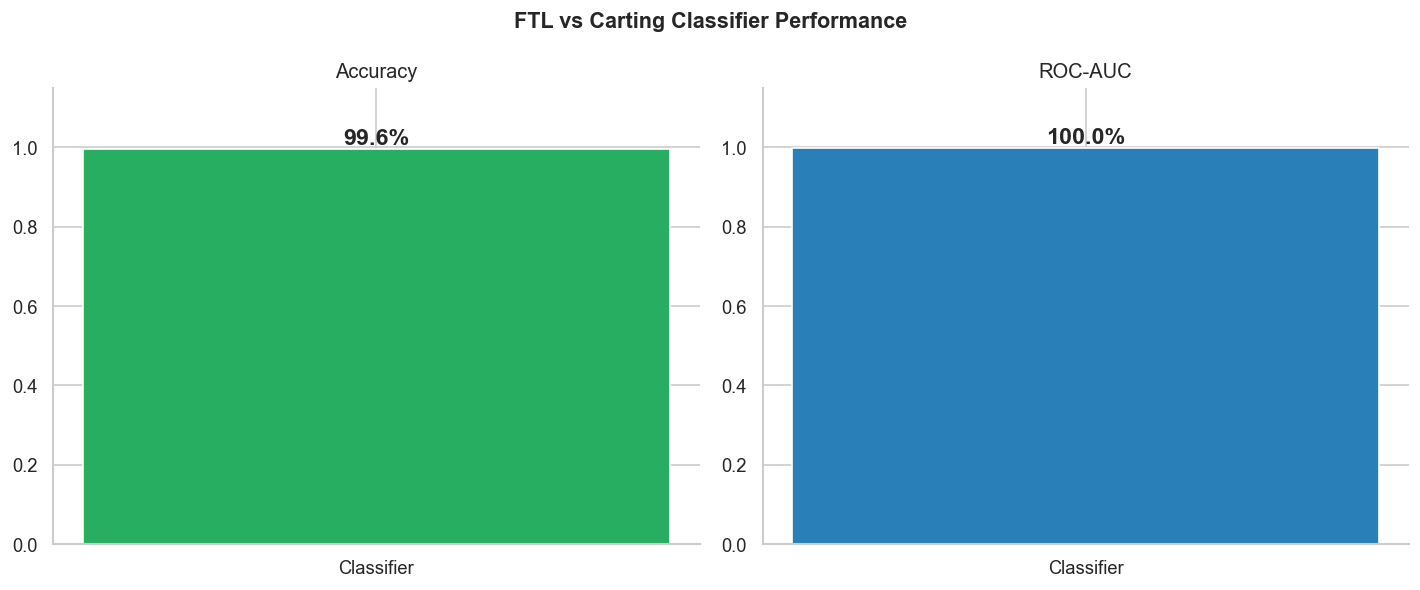

Saved 01_model_accuracy.png


In [19]:
#step 6 visualisations 
#chart 1 model accurarcy summary
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (val, lbl, col) in zip(axes, [
    (acc, "Accuracy",  "#27AE60"),
    (auc, "ROC-AUC",   "#2980B9"),
]):
    ax.bar(["Classifier"], [val], color=col, width=0.4, edgecolor="white")
    ax.text(0, val + 0.01, f"{val:.1%}", ha="center", fontsize=14, fontweight="bold")
    ax.set_title(lbl, fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.spines[["top","right"]].set_visible(False)
 
fig.suptitle("FTL vs Carting Classifier Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/01_model_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 01_model_accuracy.png")
 

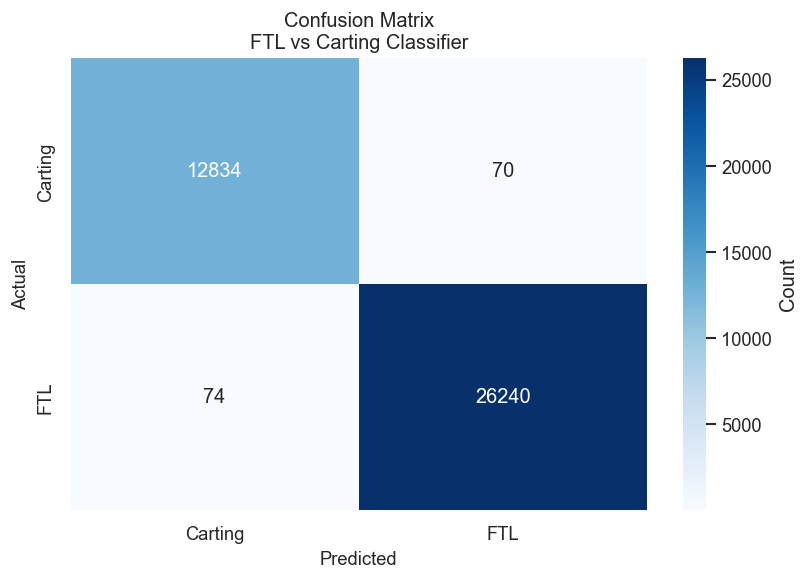

Saved 02_confusion_matrix.png


In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Carting","FTL"],
    yticklabels=["Carting","FTL"],
    ax=ax, cbar_kws={"label":"Count"}
)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual", fontsize=11)
ax.set_title("Confusion Matrix\nFTL vs Carting Classifier", fontsize=12)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/02_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 02_confusion_matrix.png")
 

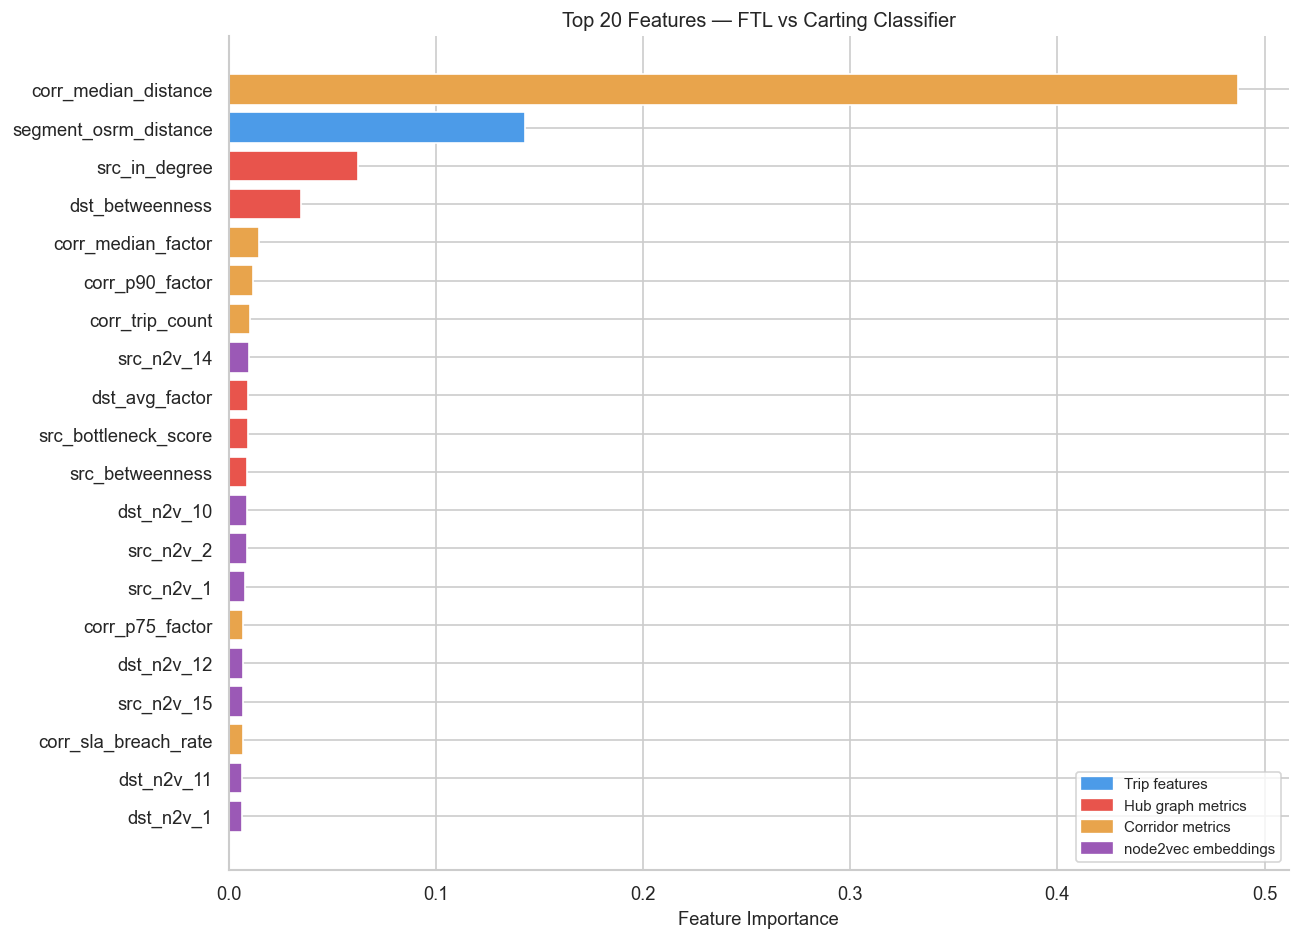

Saved 03_feature_importance.png


In [21]:
#chart 3 -> feature importance
feat_imp = pd.DataFrame({
    "feature"    : FEATURES,
    "importance" : clf.feature_importances_
}).sort_values("importance", ascending=False).head(20)
 
def feat_color(f):
    if f.startswith(("src_n2v","dst_n2v")): return "#9B59B6"
    elif f.startswith(("src_","dst_")):      return "#E8544C"
    elif f.startswith("corr_"):              return "#E8A44C"
    else:                                    return "#4C9BE8"
 
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(
    feat_imp["feature"][::-1],
    feat_imp["importance"][::-1],
    color=[feat_color(f) for f in feat_imp["feature"][::-1]],
    edgecolor="white"
)
ax.set_xlabel("Feature Importance", fontsize=11)
ax.set_title("Top 20 Features — FTL vs Carting Classifier", fontsize=12)
ax.legend(handles=[
    mpatches.Patch(color="#4C9BE8", label="Trip features"),
    mpatches.Patch(color="#E8544C", label="Hub graph metrics"),
    mpatches.Patch(color="#E8A44C", label="Corridor metrics"),
    mpatches.Patch(color="#9B59B6", label="node2vec embeddings"),
], fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/03_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 03_feature_importance.png")

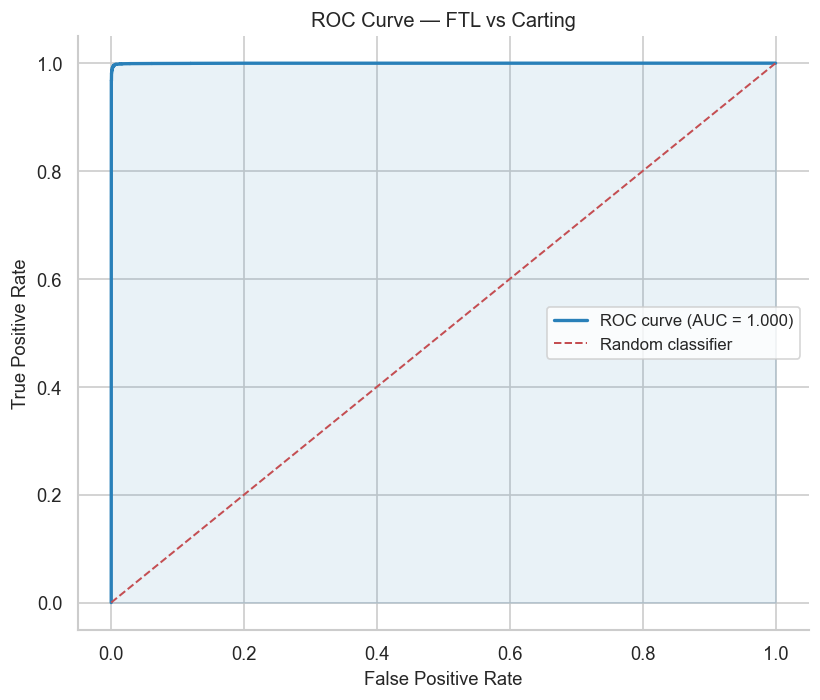

Saved 04_roc_curve.png


In [22]:
#roc curve 
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
 
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="#2980B9", linewidth=2, label=f"ROC curve (AUC = {auc:.3f})")
ax.plot([0,1],[0,1], "r--", linewidth=1.2, label="Random classifier")
ax.fill_between(fpr, tpr, alpha=0.1, color="#2980B9")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curve — FTL vs Carting", fontsize=12)
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/04_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 04_roc_curve.png")
 

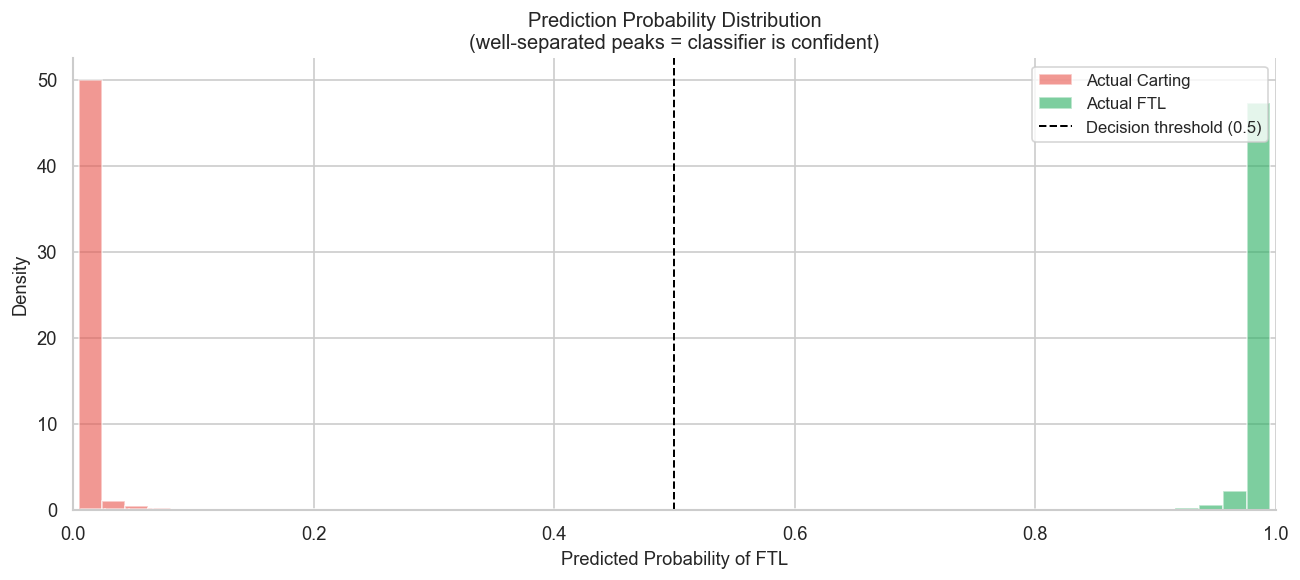

Saved 05_probability_distribution.png


In [24]:
#prob distribution 
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(y_pred_prob[y_test.values == 0], bins=50, alpha=0.6,
        color="#E8544C", label="Actual Carting", density=True)
ax.hist(y_pred_prob[y_test.values == 1], bins=50, alpha=0.6,
        color="#27AE60", label="Actual FTL", density=True)
ax.axvline(x=0.5, color="black", linestyle="--", linewidth=1.2,
           label="Decision threshold (0.5)")
ax.set_xlabel("Predicted Probability of FTL", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title(
    "Prediction Probability Distribution\n"
    "(well-separated peaks = classifier is confident)",
    fontsize=12
)
ax.set_xlim(0, 1)
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/05_probability_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 05_probability_distribution.png")


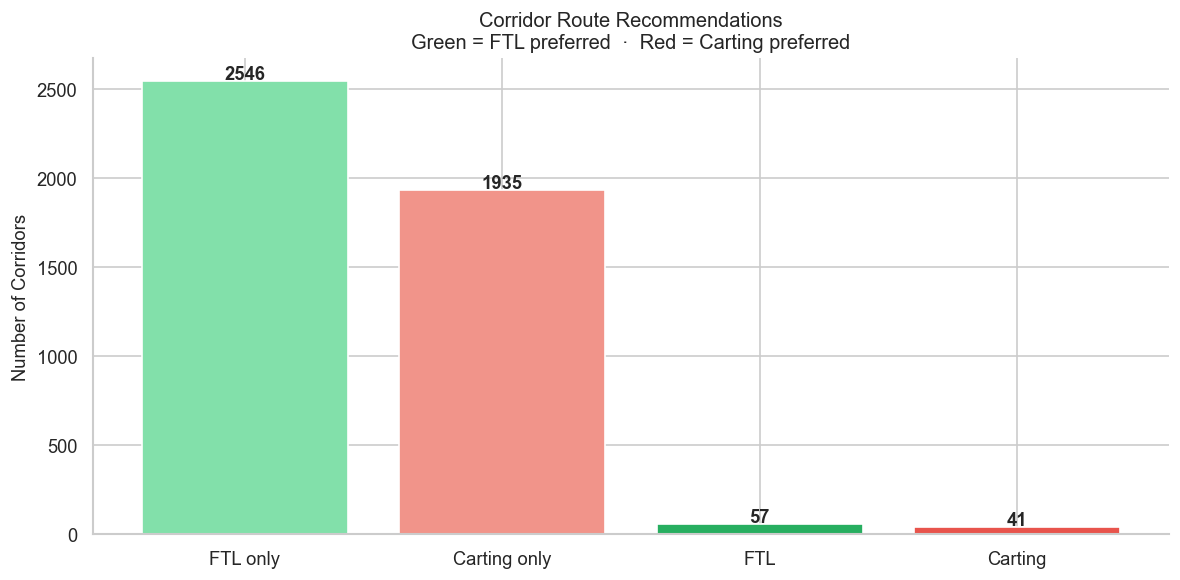

Saved 06_corridor_recommendations.png


In [25]:
#corridor recomemendation breakdoewn 
rec_counts = corridor_decisions["recommendation"].value_counts().reset_index()
rec_counts.columns = ["recommendation","count"]
 
color_map = {
    "FTL"              : "#27AE60",
    "Carting"          : "#E8544C",
    "FTL only"         : "#82E0AA",
    "Carting only"     : "#F1948A",
    "Insufficient data": "#BDC3C7",
}
 
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    rec_counts["recommendation"],
    rec_counts["count"],
    color=[color_map.get(r,"#BDC3C7") for r in rec_counts["recommendation"]],
    edgecolor="white"
)
for bar, val in zip(bars, rec_counts["count"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 10,
            str(val), ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of Corridors", fontsize=11)
ax.set_title(
    "Corridor Route Recommendations\n"
    "Green = FTL preferred  ·  Red = Carting preferred",
    fontsize=12
)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/06_corridor_recommendations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 06_corridor_recommendations.png")

In [26]:
clf.save_model(f"{OUT_DIR}/ftl_carting_model.json")
print("Saved ftl_carting_model.json")
 
with open(f"{OUT_DIR}/phase4_features.json", "w") as f:
    json.dump({"features": FEATURES, "target": TARGET}, f, indent=2)
print("Saved phase4_features.json")
 
 
# ============================================================
# CELL 21 — Final summary
# ============================================================
 
print("=" * 55)
print("  PHASE 4 COMPLETE")
print("=" * 55)
print()
print("CLASSIFIER RESULTS:")
print(f"  Accuracy  : {acc:.1%}")
print(f"  ROC-AUC   : {auc:.4f}")
print()
print("KEY FINDING:")
print("  99.4% of corridors are dedicated to one route type.")
print("  Route type is structurally determined, not freely chosen.")
print("  The classifier confirms this pattern with 99.6% accuracy.")
print()
print("CORRIDOR RECOMMENDATIONS:")
for k, v in corridor_decisions["recommendation"].value_counts().items():
    print(f"  {k:<25}: {v} corridors")
print()
print("FILES SAVED:")
files = [
    ("ftl_carting_model.json",         "XGBoost classifier"),
    ("ftl_carting_predictions.csv",    "per-trip predictions"),
    ("route_decision_framework.csv",   "per-corridor recommendations"),
    ("phase4_features.json",           "feature list"),
    ("phase4_visuals/",                "6 charts"),
]
for fname, desc in files:
    print(f"  outputs/{fname:<35} ← {desc}")
print()
print("  → Phase 5: Strategy Memo")

Saved ftl_carting_model.json
Saved phase4_features.json
  PHASE 4 COMPLETE

CLASSIFIER RESULTS:
  Accuracy  : 99.6%
  ROC-AUC   : 0.9998

KEY FINDING:
  99.4% of corridors are dedicated to one route type.
  Route type is structurally determined, not freely chosen.
  The classifier confirms this pattern with 99.6% accuracy.

CORRIDOR RECOMMENDATIONS:
  FTL only                 : 2546 corridors
  Carting only             : 1935 corridors
  FTL                      : 57 corridors
  Carting                  : 41 corridors

FILES SAVED:
  outputs/ftl_carting_model.json              ← XGBoost classifier
  outputs/ftl_carting_predictions.csv         ← per-trip predictions
  outputs/route_decision_framework.csv        ← per-corridor recommendations
  outputs/phase4_features.json                ← feature list
  outputs/phase4_visuals/                     ← 6 charts

  → Phase 5: Strategy Memo
